# **Protein complex prediction using ColabFold**

In this exercise, we will use AlphaFold-Multimer. It is intended to help you achieve the following learning objective: Use generative AI methods to predict the structure of protein complexes based on the sequence of amino acids. Express confidence in the quality of a structure prediction.

AlphaFold is a groundbreaking deep learning system developed by DeepMind that predicts protein structures from amino acid sequences with near‑experimental accuracy, a scientific advance so significant that its creators, Demis Hassabis and John Jumper (along with David Baker), were awarded the [2024 Nobel Prize in Chemistry](https://deepmind.google/blog/demis-hassabis-john-jumper-awarded-nobel-prize-in-chemistry/). Building on this foundation, **AlphaFold‑Multimer** extends the methodology to predict the structures of multi‑protein assemblies, enabling insights into protein–protein interfaces and complex formation. **ColabFold** builds on AlphaFold by providing a faster, more accessible, and more flexible interface that runs inside Google Colab. Instead of relying on AlphaFold’s original computationally intensive pipeline, ColabFold uses optimized components—most notably MMseqs2 for rapid multiple sequence alignment generation—to greatly reduce runtime while still using AlphaFold’s core model weights. In essence, AlphaFold provides the underlying predictive engine, while ColabFold packages that engine into a user‑friendly, cloud‑based workflow that allows students and researchers to run structure predictions without specialized hardware, simplifying experimentation, teaching, and rapid prototyping in structural biology.

G protein–coupled receptors (GPCRs) such as the μ opioid receptor (MOR) mediate cellular responses to hormones, neurotransmitters, and drugs. MOR activates intracellular signaling primarily through heterotrimeric G proteins (Gα, Gβ, and Gγ subunits). Understanding their structures could provide insight into ligand binding, signaling specificity, and pharmacological targeting.

In this exercise, we will:

*   Retrieve protein sequences for a MOR and G‑protein subunits.
*   Examine AlphaFold Database structures of MOR and Gα.
*   Run ColabFold for structure prediction of a MOR–G protein complex.
*   Analyze pLDDT, PAE, and structural/functional implications.
*   Compare AFDB monomer information to complex‑level predictions.

For most of this exercise, we will *not* need SDSC Expanse. Instead we will use online databases and ColabFold. ColabFold uses Google Colab, which is similar to JupyterLab but runs on temporary virtual machines using Google computing resources. Because it uses a different virtual environment and filesystem, it is not completely straightforward to adapt to SDSC Expanse. I recommend keeping notes in a text file until you start working on Expanse. In Part 4, you will use the structural visualization and alignment tools from the Exercise 2 to analyze how your predicted complex compares with a CryoEM structure. Thus, instructions for working on Expanse are included in Part 4.

The exercise will be graded based on submitting your top-ranked ColabFold structure and answers to the questions after ```-->``` on Canvas.

# **Part 1 — Retrieve Protein Sequences from UniProt**

UniProt is "the world’s leading high-quality, comprehensive and freely accessible resource of protein sequence and functional information." We will mainly use it to obtain protein sequences, but you are encouraged to explore the web pages for each protein. You should download the sequences for these proteins in **FASTA** format, which contains protein sequences with one-letter codes for each amino acid:

1. The μ Opioid Receptor. Search for **“human μ opioid receptor OPRM1”** on [UniProt](https://www.uniprot.org/) and view the canonical sequence. OPRM1 is the gene name. The FASTA file should look like this:

```
>sp|P35372|OPRM_HUMAN Mu-type opioid receptor OS=Homo sapiens OX=9606 GN=OPRM1 PE=1 SV=2
MDSSAAPTNASNCTDALAYSSCSPAPSPGSWVNLSHLDGNLSDPCGPNRTDLGGRDSLCP
PTGSPSMITAITIMALYSIVCVVGLFGNFLVMYVIVRYTKMKTATNIYIFNLALADALAT
STLPFQSVNYLMGTWPFGTILCKIVISIDYYNMFTSIFTLCTMSVDRYIAVCHPVKALDF
RTPRNAKIINVCNWILSSAIGLPVMFMATTKYRQGSIDCTLTFSHPTWYWENLLKICVFI
FAFIMPVLIITVCYGLMILRLKSVRMLSGSKEKDRNLRRITRMVLVVVAVFIVCWTPIHI
YVIIKALVTIPETTFQTVSWHFCIALGYTNSCLNPVLYAFLDENFKRCFREFCIPTSSNI
EQQNSTRIRQNTRDHPSTANTVDRTNHQLENLEAETAPLP
```

2. Your assigned [Gα subunit](https://iit0-my.sharepoint.com/:x:/g/personal/dminh_illinoistech_edu/IQCrAb-IhM4GSKfaSeYYpqjnAYQbDxRs_NXaKGANoEcriSE?e=4Fsvsc). You may view the spreadsheet if you are logged into your Illinois Tech account. Retrieve its human UniProt FASTA sequence. **Gαi1, Gαi2, Gαi3, Gαo, or Gαz** are known to couple to MOR, but we will also build models of others for comparison.

3. The shared Gβ and Gγ subunits: **Gβ1 (gene name GNB1)** and **Gγ2 (gene name GNG2)**.

# **Part 2 — Model the MOR–G Protein Complex Using ColabFold**

1.  Open the [ColabFold Notebook](https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb). ColabFold runs on Google Colab, Google's version of the JupyterLab environment that is connected to Google computing resources. Thus you will need a Google account to run it. Colab is free for limited daily use; make sure to truncate the N terminus (next step) to save compute time.

2.  Enter data and select options in the notebook.

* In the `query_sequence` field, paste the four sequences - MOR, your Gα, Gβ1, and Gγ2 - each separated by `:` and **in this order**. To save compute time (so that jobs are less likely to time out), we will use a truncated sequence for MOR from residues 61 to 375 that excludes regions that are not present in crystal structures and disordered in AlphaFold models. The first 60 residues are extracellular. In my ColabFold model with full-length MOR, the last residues do not directly interact with the G protein. This is the truncated sequence, all in one line, for easy copy and paste:
```
PTGSPSMITAITIMALYSIVCVVGLFGNFLVMYVIVRYTKMKTATNIYIFNLALADALATSTLPFQSVNYLMGTWPFGTILCKIVISIDYYNMFTSIFTLCTMSVDRYIAVCHPVKALDFRTPRNAKIINVCNWILSSAIGLPVMFMATTKYRQGSIDCTLTFSHPTWYWENLLKICVFIFAFIMPVLIITVCYGLMILRLKSVRMLSGSKEKDRNLRRITRMVLVVVAVFIVCWTPIHIYVIIKALVTIPETTFQTVSWHFCIALGYTNSCLNPVLYAFLDENFKRCFREFCIPTSSNIEQQNSTRIRQNTRDH
```
* Choose a job name `MOR_Gα complex`, where Gα is replaced by the name of your subunit.
* Make sure to save your data. Scrolling down to Advanced Settings, check `save_to_google_drive`. If you have an Ad blocker, disable it for this site.
* Keep the default options for everything else.

3. Press "Run all" in the toolbar. When I ran it, it took about 1.5 minutes to install dependencies before it asked me to give the Notebook permission to access my files on Google Drive. Then it took about 75 minutes to run the calculation on a T4 GPU. While the calculation is running, you may work on Part 3. You should check on your notebook periodically so it doesn't disconnect from inactivity. If it disconnects, you will need to start it over. If you pay for Colab Pro you can run a notebook in the background. 

4. Once the calculation is complete, **download the result files**. A file with a name like `MORGoBcomplex_09c1a.result.zip` should automatically download to the workstation and also save to your Google Drive (if you checked the box).

<!--You can also select `File->Download->Download .ipynb` to download your notebook.-->

<!--Run times for different MOR truncations:
61-354: 82 minutes
61-375: 75 minutes
61-400: 120 minutes
Full length: time out
-->

### --> What is your `query_sequence` string?

# **Part 3 — Retrieve MOR and G Protein Models from the AlphaFold Protein Structure Database**

Many AlphaFold predictions have already been made for proteins in isolation. This is the AlphaFold model for MOR:

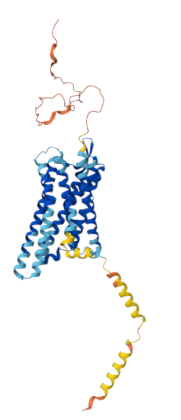

The protein comprises an extracellular N terminus of the protein, seven transmembrane helicies separated by intracellular and extracellular loops, and a intracellular C terminus. The helicies are numbered 1-7, starting from the N terminus. In the image above, the protein is oriented such that the extracellular region is on top and the intracellular region on the bottom, as is conventional in visualization of transmembrane proteins.

### --> Describe the model confidence in different parts of the structure. In which parts of the protein is the model confidence highest? In which parts of the protein is the model confidence lowest? In which transmembrane helices is model confidence the lowest?

### --> Based on your knowledge of structural determination techniques, explain why model confidence is lower in some parts of the protein.

Let's examine these predictions for MOR and the G protein subunits (with your assigned Gα).

1.  Go to **<https://alphafold.ebi.ac.uk>**.
2.  Search for the UniProt ID of MOR and the G protein subunits.
3.  For each structure, look at the 3D model, pLDDT coloring, and PAE map.
4.  Make notes on structural expectations (helices, loops, flexible regions, etc.), which you will compare to your full complex model.
5.  Download the mmCIF files to your workstation.

# **Part 4 — Analyze the Predicted MOR–G Protein Complex**

Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. To do that, log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 03-ColabFold.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/03-ColabFold.ipynb
```

To start JupyterLab, you can paste the following commands into the shell. You can adjust the time limit, but 1.5 hours is good to run for the class period and does not use too many computing resources in case you forget to shut down.

```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 01:30:00 --interface lab --conda-env visualization --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

You should also upload your ColabFold results and AlphaFold CIF structures into `exercises/03` using the *Home Directory* app in the Expanse User Portal. Once you have done that, the following cell will load your ColabFold model and a CryoEM structure, 8EF5, a complex of MOR that includes Gαi1.

In [ ]:
import os, zipfile, prody

# Unpack and identify the best-ranked structure and corresponding json from ColabFold
jobname = next(FN for FN in os.listdir('03') if FN.endswith('.result.zip'))[:-11]
with zipfile.ZipFile(os.path.join('03',jobname+'.result.zip'), 'r') as zip_ref:
    zip_ref.extractall('03')
rank1_pdb_FN = next(FN for FN in os.listdir(os.path.join('03',jobname)) if FN.find('rank_001')>-1 and FN.endswith('.pdb'))

# Load the PDB files for the cryoEM and predicted complexes into prody
import prody
PDB_cryo = prody.parsePDB('8EF5')
PDB_CF = prody.parsePDB(os.path.join('03',jobname,rank1_pdb_FN))
    
# Superpose the files based on aligning the receptor structure
map_from_CF_to_cryo, map_from_cryo_to_CF, seqid, overlap = \
  prody.matchChains(PDB_CF.select('protein and chain A and resid 1 to 300'),PDB_cryo.select('protein and chain R'))[0]
transformation = prody.calcTransformation(map_from_CF_to_cryo, map_from_cryo_to_CF) # Calculate a transformation that superposes the chains
prody.applyTransformation(transformation, PDB_CF) # Apply the transformation

The next cell should display the ColabFold structure (colored by plddt) and the cryoEM structure (in grey). You may want to toggle the cryoEM structure on or off by clicking the eye-like symbol in the gui.

In [ ]:
import nglview as nv
view = nv.NGLWidget()
view.add_component(PDB_cryo.select('protein and (chain R or chain A or chain B or chain C)'))
view[0].clear_representations()
view[0].add_representation("cartoon", color="grey", opacity=0.5)
view.add_component(PDB_CF)
view[1].clear_representations()
view[1].add_representation('cartoon')
# view[1].add_representation('cartoon', colorScheme='bfactor', colorDomain=[0.0, 100.0])
view.shape.add_text(prody.measure.calcCenter(PDB_cryo.select('chain R')), [0., 1., 0.5], 10, "MOR")
view.shape.add_text(prody.measure.calcCenter(PDB_cryo.select('chain A')), [0., 1., 0.5], 10, "G alpha")
view.shape.add_text(prody.measure.calcCenter(PDB_cryo.select('chain B')), [0., 1., 0.5], 10, "G beta")
view.shape.add_text(prody.measure.calcCenter(PDB_cryo.select('chain C and resnum 1 to 25')), [0., 1., 0.5], 10, "G gamma")
view.display(gui=True)

### --> Describe the relative orientation of all the chains: MOR and the G protein subunits. Is the arrangement of chains in the ColabFold model qualitatively similar to the CryoEM structure?

In [ ]:
from IPython.display import Image
Image(os.path.join('03',jobname,jobname+'_plddt.png'))

### --> In which regions of the complex does AlphaFold2 have the least confidence?

In [ ]:
Image(os.path.join('03',jobname,jobname+'_pae.png'))

### --> How well-determined is the alignment between chains? Which G protein subunit has be best-determined alignment with MOR? Which pair of G protein subunits has the best-determined alignment?

## Individual subunits

The next cell compares the ColabFold and AlphaFold models of each chain. Change the UniProtID dictionary to your Gα and change the `subunit` variable to select a specific chain.

In [ ]:
subunit = 'Gα' # Change this to view a different subunit
UniProtID = {
    'MOR':'P35372',
    'Gα':'P09471-2', # Set this to your subunit
    'Gβ':'P62873',
    'Gγ':'P59768'}
CF_ChID = {'MOR':'A', 'Gα':'B', 'Gβ':'C', 'Gγ':'D'}

PDB_AF = prody.parseCIF(os.path.join('03',f'AF-{UniProtID[subunit]}-F1-model_v6.cif'))  
# Superpose the AlphaFold onto the ColabFold model
map_from_AF_to_CF, map_from_CF_to_AF, seqid, overlap = prody.matchChains(\
    PDB_AF.select('resnum 61 to 400' if subunit=='MOR' else 'protein'),\
    PDB_CF.select('chain '+CF_ChID[subunit]),overlap=70,pwalign=True)[0]
transformation = prody.calcTransformation(map_from_AF_to_CF, map_from_CF_to_AF) # Calculate a transformation that superposes the chains
prody.applyTransformation(transformation, PDB_AF) # Apply the transformation

view = nv.NGLWidget()
view.add_component(PDB_CF.select('chain '+CF_ChID[subunit]))
view[0].clear_representations()
view[0].add_representation('cartoon', colorScheme='bfactor', colorDomain=[0.0, 100.0])
view.add_component(PDB_AF)
view[1].clear_representations()
view[1].add_representation('cartoon', opacity=0.75, colorScheme='bfactor', colorDomain=[0.0, 100.0])
view.display(gui=True)

### --> Compare the modeled structures of each monomeric chain to the complex. For each chain, where (if anywhere) are there significant structural differences? Where are there different levels of confidence?

# Part 5 — End the session

To end the JupyterLab session, you should click on `File->Shut Down`. Closing your browser tab does **not** necessarily stop the job. You can find your running jobs with `squeue -u $USER` and cancel a job with `scancel <JOBID>` (replace `<JOBID>`).

When you are done with this exercise, save the file in ~/exercises. Submit your top-ranked ColabFold structure and answers to the questions after ```-->``` on Canvas.